# Sensitivity Analysis of Sequentially Trained Models

We perform sensitivity analysis to understand how each input feature contributes to the model's anomaly detection, identifying which features are most influential.

**Methods:**
- **Integrated Gradients (IG)**: Applied to the PNN model (`maximize_sigma`) and the PRAE model (`maximize_rec_error`). Provides per-feature attribution scores for individual samples.
- **Grouped Occlusion**: Applied to the Transformer+OC-SVM model. Occludes groups of features (by `type` and `side`) and measures the change in anomaly score.

In [ ]:
import os, sys, math, logging, glob, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import joblib

sys.path.insert(0, os.path.abspath(".."))

from detection.data.loaders import create_sequences, load_processed
from detection.models.hybrid import TransformerOCSVM
from detection.models.pnn import PNN
from detection.models.prae import PRAE
from detection.models.transformer import BottleneckTransformer
from detection.sensitivity.integrated_gradients import IntegratedGradients, maximize_sigma, maximize_rec_error
from detection.sensitivity.occlusion import GroupedOcclusion

from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
logger = logging.getLogger(__name__)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


Device: cuda


## Configuration & Data Preparation

In [ ]:
DATA_DIR = os.path.join("..", "data", "processed", "TOTF.PA-book")
RESULTS_DIR = os.path.join("..", "results")
SEQ_LENGTH = 25
BATCH_SIZE = 64
N_IG_STEPS = 50
N_SAMPLES = 10

LOB_COLUMNS = [
    f"{side}-{typ}-{lvl}"
    for lvl in range(1, 11)
    for side, typ in [("bid","price"),("bid","volume"),("ask","price"),("ask","volume")]
]

FILES = sorted(glob.glob(os.path.join(DATA_DIR, "*.parquet")))
TEST_FILE = FILES[-1]

_, features_test = load_processed(TEST_FILE, "xltime", LOB_COLUMNS)
features_test = features_test.iloc[:10000]
print(f"Test day: {os.path.basename(TEST_FILE)}")
print(f"Rows: {len(features_test)}, Features: {len(features_test.columns)}")


Test day: 2015-02-05-TOTF.PA-book.parquet
Rows: 10000, Features: 89


## Load Models & Prepare Sequences

In [3]:
models = {}   # model_type -> (model, ocsvm_or_None)
scalers = {}
feat_names_map = {}

for model_type in ["transformer_ocsvm", "pnn", "prae"]:
    # Feature names
    feat_path = os.path.join(RESULTS_DIR, f"{model_type}_features.txt")
    if os.path.exists(feat_path):
        with open(feat_path) as f:
            feat_names = [l.strip() for l in f if l.strip()]
    else:
        feat_names = features_test.columns.tolist()
    feat_names_map[model_type] = feat_names

    # Scaler
    scaler_path = os.path.join(RESULTS_DIR, f"{model_type}_scaler.pkl")
    scalers[model_type] = joblib.load(scaler_path) if os.path.exists(scaler_path) else MinMaxScaler()

    # Model
    num_features = len(feat_names)
    weights_path = os.path.join(RESULTS_DIR, f"{model_type}_weights.pth")

    if model_type == "transformer_ocsvm":
        transformer = BottleneckTransformer(
            num_features=num_features, model_dim=64, num_heads=4,
            num_layers=2, representation_dim=128, sequence_length=SEQ_LENGTH)
        transformer.load_state_dict(torch.load(weights_path, map_location=DEVICE, weights_only=True))
        transformer.eval().to(DEVICE)
        # Nyström OC-SVM saved as PyTorch module
        ocsvm_path = weights_path.replace("_weights.pth", "_detector.pth")
        ocsvm = torch.load(ocsvm_path, map_location=DEVICE, weights_only=False) if os.path.exists(ocsvm_path) else None
        models[model_type] = (transformer, ocsvm)

    elif model_type == "pnn":
        input_dim = SEQ_LENGTH * num_features
        model = PNN(input_dim=input_dim, hidden_dim=64).to(DEVICE)
        model.load_state_dict(torch.load(weights_path, map_location=DEVICE, weights_only=True))
        model.eval()
        models[model_type] = (model, None)

    elif model_type == "prae":
        backbone = BottleneckTransformer(
            num_features=num_features, model_dim=64, num_heads=4,
            num_layers=2, representation_dim=128, sequence_length=SEQ_LENGTH)
        model = PRAE(backbone_model=backbone, num_train_samples=1, lambda_reg=1.0, sigma=0.5).to(DEVICE)
        state_dict = torch.load(weights_path, map_location=DEVICE, weights_only=True)
        state_dict = {k: v for k, v in state_dict.items() if k != "mu"}
        model.load_state_dict(state_dict, strict=False)
        model.eval()
        models[model_type] = (model, None)

    print(f"Loaded {model_type}")


def prepare_sequences(model_type):
    """Scale + sequence the test data for a given model type."""
    feat_names = feat_names_map[model_type]
    feat_df = features_test.copy()
    for col in feat_names:
        if col not in feat_df.columns:
            feat_df[col] = 0.0
    feat_df = feat_df[feat_names]
    scaler = scalers[model_type]
    scaled = scaler.transform(feat_df.values.astype(np.float32)).astype(np.float32)
    sequences = create_sequences(scaled, SEQ_LENGTH)
    return torch.tensor(sequences, dtype=torch.float32), scaled, feat_names

print("All models loaded.")

Loaded transformer_ocsvm
Loaded pnn
Loaded prae
All models loaded.


## Identify Top Anomaly Samples

We compute anomaly scores for each model and select the top-N samples to explain.

In [4]:
top_indices = {}  # model_type -> array of top anomaly indices into sequences

for model_type in ["pnn", "prae", "transformer_ocsvm"]:
    x_seq, scaled, feat_names = prepare_sequences(model_type)
    model, ocsvm = models[model_type]

    if model_type == "pnn":
        # NLL scores
        target_idx = feat_names.index("log_return") if "log_return" in feat_names else 0
        targets = scaled[SEQ_LENGTH:, target_idx]
        x_flat = x_seq.reshape(x_seq.size(0), -1).to(DEVICE)
        y = torch.tensor(targets[:len(x_flat)], dtype=torch.float32).unsqueeze(1).to(DEVICE)
        with torch.no_grad():
            mu, sigma, alpha = model(x_flat)
            z = (y - mu) / sigma
            phi_z = (1.0 / math.sqrt(2 * math.pi)) * torch.exp(-0.5 * z**2)
            big_phi = 0.5 * (1 + torch.erf(alpha * z / math.sqrt(2)))
            pdf = (2.0 / sigma) * phi_z * big_phi
            nll = -torch.log(pdf + 1e-10)
            scores = nll.cpu().numpy().flatten()

    elif model_type == "prae":
        loader = DataLoader(TensorDataset(x_seq, x_seq), batch_size=BATCH_SIZE, shuffle=False)
        sc_list = []
        with torch.no_grad():
            for b in loader:
                x = b[0].to(DEVICE)
                rec, _ = model(x, training=False)
                sc_list.append(torch.sum((x - rec)**2, dim=tuple(range(1, x.dim()))).cpu().numpy())
        scores = np.concatenate(sc_list)

    elif model_type == "transformer_ocsvm":
        loader = DataLoader(TensorDataset(x_seq, x_seq), batch_size=BATCH_SIZE, shuffle=False)
        if ocsvm is not None:
            det = TransformerOCSVM.__new__(TransformerOCSVM)
            det.transformer = model
            det.ocsvm = ocsvm
            scores = det.predict(loader)
        else:
            sc_list = []
            with torch.no_grad():
                for b in loader:
                    x = b[0].to(DEVICE)
                    rec = model(x)
                    sc_list.append(torch.mean((x - rec)**2, dim=(1,2)).cpu().numpy())
            scores = np.concatenate(sc_list)

    # Top N anomalies
    top_idx = np.argsort(scores)[-N_SAMPLES:][::-1]
    top_indices[model_type] = top_idx
    print(f"{model_type}: top {N_SAMPLES} anomaly indices = {top_idx.tolist()}")
    print(f"  scores: {scores[top_idx].tolist()}")

pnn: top 10 anomaly indices = [7983, 7581, 8123, 7597, 8870, 7419, 9974, 7599, 3702, 7604]
  scores: [7.202896595001221, 6.805723667144775, 6.5521063804626465, 5.820491790771484, 5.611216068267822, 5.549410343170166, 5.370194911956787, 5.277032375335693, 5.273966312408447, 5.260584831237793]
prae: top 10 anomaly indices = [2449, 2450, 2451, 2448, 2447, 2446, 2452, 2445, 2453, 2454]
  scores: [4908.2626953125, 4901.974609375, 4898.02783203125, 4886.408203125, 4881.0361328125, 4835.83203125, 4835.6064453125, 4799.015625, 4786.724609375, 4761.9990234375]
transformer_ocsvm: top 10 anomaly indices = [8961, 8965, 9264, 3653, 3656, 8964, 3655, 3651, 9268, 8963]
  scores: [-0.019267365336418152, -0.019322216510772705, -0.019546538591384888, -0.019719645380973816, -0.020008280873298645, -0.020239710807800293, -0.020536303520202637, -0.02083262801170349, -0.020873934030532837, -0.021033495664596558]


## Integrated Gradients -- PNN (`maximize_sigma`)

For the PNN model, we use IG with `maximize_sigma` as the target function. The PNN forward pass expects flattened inputs; IG expects (1, Seq, Feat). We reshape internally.

PNN -- Top 15 features by mean |IG attribution| (maximize_sigma):


,Feature,Mean |Attribution|
2,mid_price,1.482571
83,Hawkes_M_ask_beta1000,0.226081
22,abs_velocity,0.169465
82,Hawkes_M_bid_beta1000,0.132474
71,Hawkes_L_ask_beta1000_Eta0.001,0.109569
16,bid_sweep_cost,0.104451
39,SMA_trade_ask,0.091663
81,Hawkes_M_ask_beta100,0.089415
32,size_trade_bid,0.085435
42,rapidity_trade_bid,0.084716


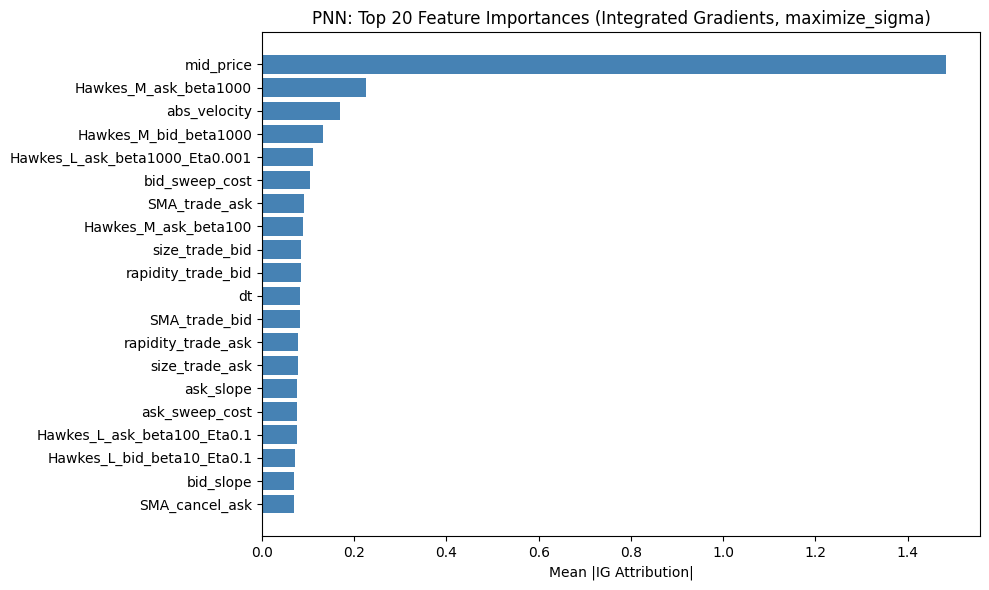

In [5]:
x_seq_pnn, _, feat_names_pnn = prepare_sequences("pnn")
pnn_model = models["pnn"][0]

# Wrap PNN to accept (Batch, Seq, Feat) and reshape internally
class PNNSeqWrapper(torch.nn.Module):
    def __init__(self, pnn):
        super().__init__()
        self.pnn = pnn
    def forward(self, x):
        flat = x.reshape(x.size(0), -1)
        return self.pnn(flat)

pnn_wrapper = PNNSeqWrapper(pnn_model).to(DEVICE)
ig_pnn = IntegratedGradients(pnn_wrapper)

# Compute attributions for top anomalies
pnn_attributions = []
for idx in top_indices["pnn"]:
    sample = x_seq_pnn[idx].unsqueeze(0).to(DEVICE)  # (1, Seq, Feat)
    attrs = ig_pnn.attribute(sample, target_func=maximize_sigma, n_steps=N_IG_STEPS)
    pnn_attributions.append(attrs.detach().cpu().numpy().squeeze())

# Aggregate: mean absolute attribution per feature (averaged over time steps and samples)
pnn_attr_array = np.array(pnn_attributions)  # (N_SAMPLES, Seq, Feat)
mean_attr_per_feature = np.mean(np.abs(pnn_attr_array), axis=(0, 1))  # (Feat,)

pnn_importance = pd.DataFrame({
    "Feature": feat_names_pnn,
    "Mean |Attribution|": mean_attr_per_feature
}).sort_values("Mean |Attribution|", ascending=False)

print("PNN -- Top 15 features by mean |IG attribution| (maximize_sigma):")
display(pnn_importance.head(15))

# Bar chart
fig, ax = plt.subplots(figsize=(10, 6))
top20 = pnn_importance.head(20)
ax.barh(top20["Feature"][::-1], top20["Mean |Attribution|"][::-1], color="steelblue")
ax.set_xlabel("Mean |IG Attribution|")
ax.set_title("PNN: Top 20 Feature Importances (Integrated Gradients, maximize_sigma)")
plt.tight_layout()
plt.show()

## Integrated Gradients -- PRAE (`maximize_rec_error`)

For the PRAE model, the target function measures reconstruction error, highlighting which features are hardest to reconstruct for anomalous samples.

PRAE -- Top 15 features by mean |IG attribution| (maximize_rec_error):


,Feature,Mean |Attribution|
2,mid_price,114.074562
72,Hawkes_L_bid_beta1000_Eta0.1,20.408739
76,Hawkes_L_bid_beta1000_Eta10.0,11.340875
75,Hawkes_L_ask_beta1000_Eta1.0,10.068686
74,Hawkes_L_bid_beta1000_Eta1.0,9.169988
77,Hawkes_L_ask_beta1000_Eta10.0,6.641628
59,Hawkes_L_ask_beta10_Eta1.0,6.048302
68,Hawkes_L_bid_beta100_Eta10.0,5.899086
63,Hawkes_L_ask_beta100_Eta0.001,5.153938
53,Deep_order_insertion_ask,4.718403


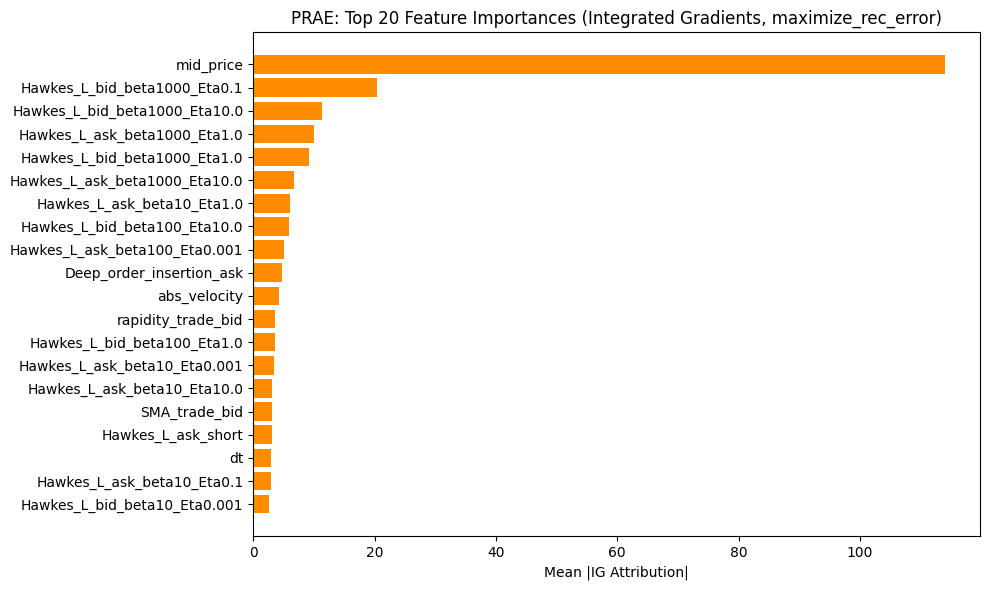

In [6]:
x_seq_prae, _, feat_names_prae = prepare_sequences("prae")
prae_model = models["prae"][0]

# PRAE forward returns (reconstructed, z). IG target_func receives (output, inputs).
# maximize_rec_error already handles this: rec = output[0], then sum((inputs - rec)**2)
ig_prae = IntegratedGradients(prae_model)

prae_attributions = []
for idx in top_indices["prae"]:
    sample = x_seq_prae[idx].unsqueeze(0).to(DEVICE)  # (1, Seq, Feat)
    attrs = ig_prae.attribute(sample, target_func=maximize_rec_error, n_steps=N_IG_STEPS)
    prae_attributions.append(attrs.detach().cpu().numpy().squeeze())

prae_attr_array = np.array(prae_attributions)  # (N_SAMPLES, Seq, Feat)
mean_attr_prae = np.mean(np.abs(prae_attr_array), axis=(0, 1))  # (Feat,)

prae_importance = pd.DataFrame({
    "Feature": feat_names_prae,
    "Mean |Attribution|": mean_attr_prae
}).sort_values("Mean |Attribution|", ascending=False)

print("PRAE -- Top 15 features by mean |IG attribution| (maximize_rec_error):")
display(prae_importance.head(15))

fig, ax = plt.subplots(figsize=(10, 6))
top20 = prae_importance.head(20)
ax.barh(top20["Feature"][::-1], top20["Mean |Attribution|"][::-1], color="darkorange")
ax.set_xlabel("Mean |IG Attribution|")
ax.set_title("PRAE: Top 20 Feature Importances (Integrated Gradients, maximize_rec_error)")
plt.tight_layout()
plt.show()

## Grouped Occlusion -- Transformer + OC-SVM

We use `GroupedOcclusion` to measure the impact of occluding feature groups on the OC-SVM anomaly score. We run two groupings: by **feature type** and by **side** (bid / ask / neutral).


Transformer+OC-SVM Grouped Occlusion (group_by='type'):


,Group,Importance,Importance_Per_Feature,Num_Features
0,imbalance,8.344650e-08,1.668930e-08,5
1,dynamics,0.000000e+00,0.000000e+00,1
2,speed,0.000000e+00,0.000000e+00,2
3,spread,0.000000e+00,0.000000e+00,1
4,return,-4.470349e-09,-1.490116e-09,3
5,trade,-7.450581e-09,-1.241763e-09,6
6,sma,-6.513893e-05,-3.256947e-05,2
7,volatility,-6.846785e-05,-3.423393e-05,2
8,slope,-1.076654e-04,-5.383268e-05,2
9,time,-2.140492e-04,-1.070246e-04,2


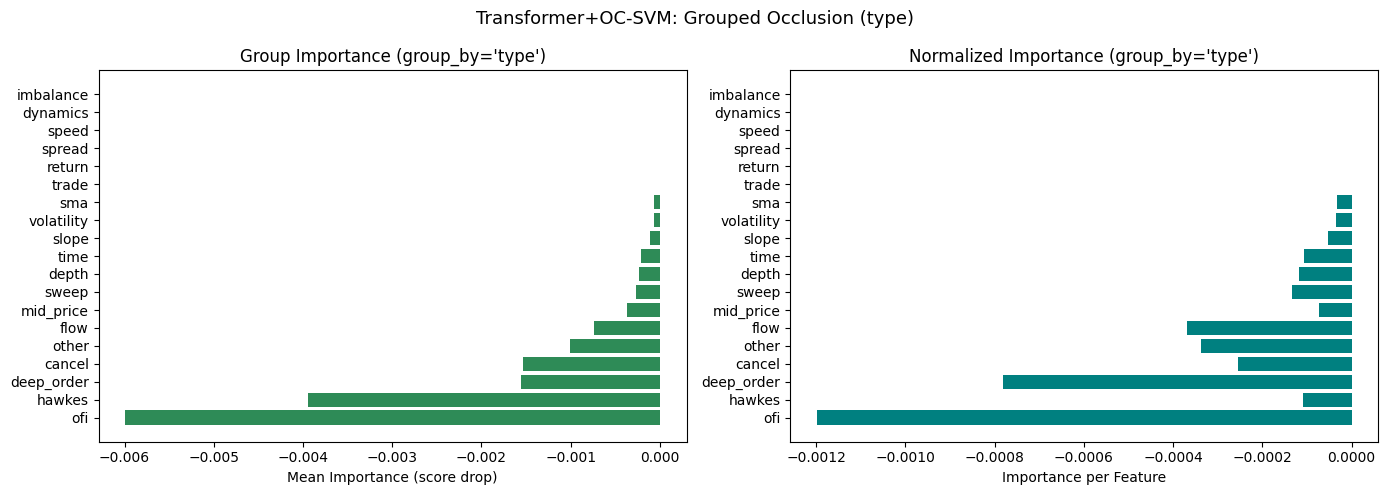


Transformer+OC-SVM Grouped Occlusion (group_by='side'):


,Group,Importance,Importance_Per_Feature,Num_Features
0,bid,-0.003616,-0.000110,33
1,ask,-0.003809,-0.000115,33
2,neutral,-0.007112,-0.000309,23


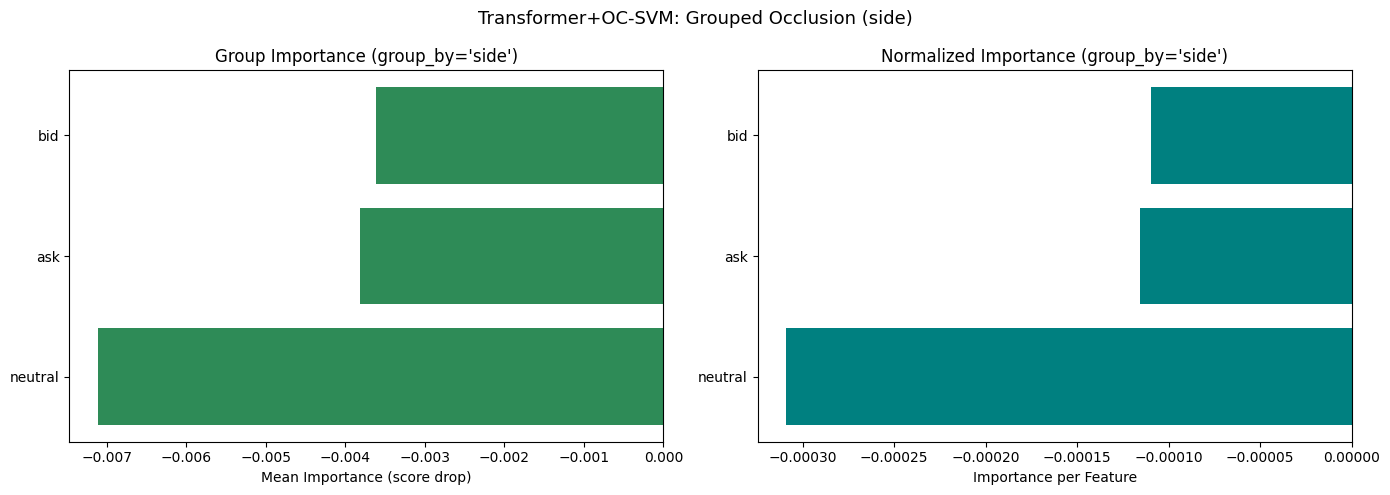

In [7]:
x_seq_tocsvm, _, feat_names_tocsvm = prepare_sequences("transformer_ocsvm")
transformer, ocsvm = models["transformer_ocsvm"]

if ocsvm is None:
    print("WARNING: OC-SVM not found; Grouped Occlusion requires the full TransformerOCSVM detector. Skipping.")
else:
    # Build a detector object for GroupedOcclusion
    detector = TransformerOCSVM.__new__(TransformerOCSVM)
    detector.transformer = transformer
    detector.ocsvm = ocsvm

    # Run grouped occlusion for each top anomaly, with two groupings
    for group_by in ["type", "side"]:
        all_importance_dfs = []
        all_feature_lists = {}

        for idx in top_indices["transformer_ocsvm"]:
            sample = x_seq_tocsvm[idx].unsqueeze(0).to(DEVICE)
            imp_df, feat_lists = GroupedOcclusion(
                detector, sample, feat_names_tocsvm,
                group_by=group_by, baseline_mode="mean")
            all_importance_dfs.append(imp_df)
            all_feature_lists.update(feat_lists)

        # Average importance across samples
        avg_imp = pd.concat(all_importance_dfs).groupby("Group").agg({
            "Importance": "mean",
            "Importance_Per_Feature": "mean",
            "Num_Features": "first",
        }).sort_values("Importance", ascending=False).reset_index()

        print(f"\nTransformer+OC-SVM Grouped Occlusion (group_by='{group_by}'):")
        display(avg_imp)

        # Plot
        fig, axes_occ = plt.subplots(1, 2, figsize=(14, 5))

        ax1 = axes_occ[0]
        ax1.barh(avg_imp["Group"][::-1], avg_imp["Importance"][::-1], color="seagreen")
        ax1.set_xlabel("Mean Importance (score drop)")
        ax1.set_title(f"Group Importance (group_by='{group_by}')")

        ax2 = axes_occ[1]
        ax2.barh(avg_imp["Group"][::-1], avg_imp["Importance_Per_Feature"][::-1], color="teal")
        ax2.set_xlabel("Importance per Feature")
        ax2.set_title(f"Normalized Importance (group_by='{group_by}')")

        plt.suptitle(f"Transformer+OC-SVM: Grouped Occlusion ({group_by})", fontsize=13)
        plt.tight_layout()
        plt.show()

## Cross-Model Feature Importance Comparison

Top 15 features by average normalized importance (PNN + PRAE):


,Feature,PNN_attr,PRAE_attr,PNN_attr_norm,PRAE_attr_norm,avg_norm
66,mid_price,1.482571,114.074562,1.000000,1.000000,1.000000
17,Hawkes_L_bid_beta1000_Eta0.1,0.010379,20.408739,0.007001,0.178907,0.092954
32,Hawkes_M_ask_beta1000,0.226081,0.316893,0.152492,0.002778,0.077635
49,abs_velocity,0.169465,4.235658,0.114305,0.037131,0.075718
19,Hawkes_L_bid_beta1000_Eta10.0,0.013328,11.340875,0.008990,0.099416,0.054203
4,Hawkes_L_ask_beta1000_Eta1.0,0.022380,10.068686,0.015095,0.088264,0.051680
36,Hawkes_M_bid_beta1000,0.132474,0.678725,0.089354,0.005950,0.047652
18,Hawkes_L_bid_beta1000_Eta1.0,0.013307,9.169988,0.008976,0.080386,0.044681
81,rapidity_trade_bid,0.084716,3.649822,0.057141,0.031995,0.044568
12,Hawkes_L_ask_beta10_Eta1.0,0.047554,6.048302,0.032075,0.053021,0.042548


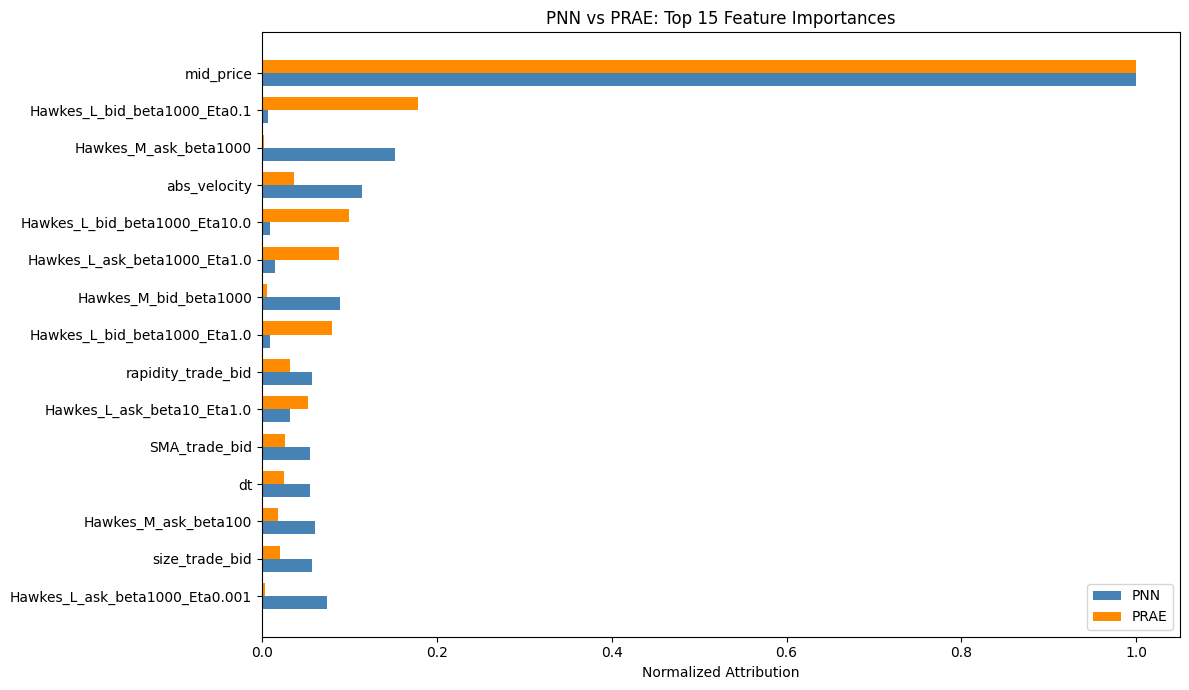

In [8]:
# Compare PNN and PRAE top features side by side
merged = pnn_importance.rename(columns={"Mean |Attribution|": "PNN_attr"}).merge(
    prae_importance.rename(columns={"Mean |Attribution|": "PRAE_attr"}),
    on="Feature", how="outer"
).fillna(0)

# Normalize to [0, 1] for comparison
for col in ["PNN_attr", "PRAE_attr"]:
    mx = merged[col].max()
    if mx > 0:
        merged[col + "_norm"] = merged[col] / mx
    else:
        merged[col + "_norm"] = 0

# Average rank
merged["avg_norm"] = (merged["PNN_attr_norm"] + merged["PRAE_attr_norm"]) / 2
merged = merged.sort_values("avg_norm", ascending=False)

print("Top 15 features by average normalized importance (PNN + PRAE):")
display(merged[["Feature", "PNN_attr", "PRAE_attr", "PNN_attr_norm", "PRAE_attr_norm", "avg_norm"]].head(15))

# Side-by-side plot
fig, ax = plt.subplots(figsize=(12, 7))
top15 = merged.head(15)
y_pos = np.arange(len(top15))
width = 0.35
ax.barh(y_pos - width/2, top15["PNN_attr_norm"].values[::-1], width, label="PNN", color="steelblue")
ax.barh(y_pos + width/2, top15["PRAE_attr_norm"].values[::-1], width, label="PRAE", color="darkorange")
ax.set_yticks(y_pos)
ax.set_yticklabels(top15["Feature"].values[::-1])
ax.set_xlabel("Normalized Attribution")
ax.set_title("PNN vs PRAE: Top 15 Feature Importances")
ax.legend()
plt.tight_layout()
plt.show()